In [1]:
! python3 -c "import cv2; print(cv2.getBuildInformation())" | grep GStreamer

    GStreamer:                   YES (1.20.3)


In [ ]:
import cv2
import os
import glob
from collections import OrderedDict
from ipywidgets import IntSlider, Label, Button, HBox
from ipycanvas import MultiCanvas, hold_canvas

thickness = 3
y_ratio = 0.75     # percentile of y-position from the top

# 🔽 이미지 파일 목록 불러오기
image_dir = '/home/ircv15/em7/perception/images0513two'
image_files = sorted(glob.glob(os.path.join(image_dir, '20250513_*.jpg')))
num_frames = len(image_files)

ann_filename = 'images0513two/annotation.txt'
ann_dict = OrderedDict()
cur_index = 0

# 첫 이미지 크기 가져오기
height, width = cv2.imread(image_files[0]).shape[:2]
y_value = int(height * y_ratio)

def set_image():
    image = cv2.imread(image_files[cur_index])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image[y_value-thickness//2:y_value+thickness//2] = (255, 0, 0)

    canvas[0].clear()
    canvas[0].put_image_data(image, 0, 0)
    canvas[0].flush()

    pos = ann_dict.get(image_files[cur_index])
    if pos is not None:
        handle_mouse_down(pos[0], pos[1])

    cur_fname.value = f'Current image: {os.path.basename(image_files[cur_index])} | '

def handle_mouse_move(xpos, ypos):
    with hold_canvas():
        canvas[1].clear()
        canvas[1].fill_style = "yellow"
        canvas[1].fill_circle(xpos, y_value, 5)

def handle_mouse_down(xpos, ypos):
    with hold_canvas():
        canvas[2].clear()
        canvas[2].fill_style = "green"
        canvas[2].fill_circle(xpos, y_value, 5)

    cur_pos.value = f"({int(xpos)}, {int(y_value)})"
    ann_dict[image_files[cur_index]] = (xpos, y_value)

def handle_slider_change(change):
    global y_value
    y_value = change.new
    set_image()
    canvas[1].clear()
    canvas[2].clear()

def handle_save_button(b):
    with open(ann_filename, 'w') as f:
        for k, v in ann_dict.items():
            f.write(f"{k}\t{int(v[0])}\t{int(v[1])}\n")

def handle_prev_button(b):
    global cur_index
    cur_index = max(0, cur_index - 1)
    canvas.clear()
    set_image()

def handle_next_button(b):
    global cur_index
    cur_index = min(num_frames - 1, cur_index + 1)
    canvas.clear()
    set_image()

canvas = MultiCanvas(3, width=width, height=height)
cur_fname = Label(value='', disabled=False)
cur_pos = Label(value='', disabled=True)
yslider = IntSlider(description="Y-bar: ", value=y_value, min=1, max=height-2, step=1)
prev_btn = Button(description='Prev', icon='arrow-left')
next_btn = Button(description='Next', icon='arrow-right')
save_btn = Button(description='Save labels', icon='check')

set_image()
canvas.on_mouse_move(handle_mouse_move)
canvas.on_mouse_down(handle_mouse_down)
yslider.observe(handle_slider_change, names='value')
prev_btn.on_click(handle_prev_button)
next_btn.on_click(handle_next_button)
save_btn.on_click(handle_save_button)

display(canvas, HBox([cur_fname, cur_pos, yslider]), HBox([prev_btn, next_btn, save_btn]))


MultiCanvas(height=720, width=1280)

In [1]:
import torch
import torchvision

def get_model():
    model = torchvision.models.alexnet(num_classes=2, dropout=0.0)
    return model

device = torch.device('cuda')
model = get_model()
model = model.to(device)

In [2]:
import torch
from cnn.center_dataset import CenterDataset

batch_size = 4

dataset = CenterDataset('images0513two', random_hflip=False)
train_loader = torch.utils.data.DataLoader(
    dataset,
    num_workers=0,
    batch_size=batch_size,
    shuffle=True,
)

In [3]:
import ipywidgets
import torch.nn.functional as f

epoch = 200
learning_rate = 2e-3
# learning_rate = 2e-4

epoch_slider = ipywidgets.IntSlider(description='Epochs', value=epoch, min=1, max=200, step=1)
lr_slider = ipywidgets.FloatSlider(description='lr', value=learning_rate, min=1e-4, max=1e-2, step=1e-4, readout_format='.4f')
train_button = ipywidgets.Button(description='Train', icon='tasks')
loss_text = ipywidgets.Textarea(description='Progress', value='', rows=15, layout=ipywidgets.Layout(width="50%", height="auto"))
layout = ipywidgets.VBox([ipywidgets.HBox([epoch_slider, lr_slider, train_button]), loss_text])


def train_model(b):
    global epoch_slider
    for epoch in range(epoch_slider.value):
        loss_text.value += "<<<<< Epoch {:d} >>>>>\n".format(epoch)
        train_step()


def train_step():
    global model, lr_slider, loss_text, train_laoder, device

    try:
        # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr_slider.value, momentum=0.9)

        train_button.disabled = True
        model = model.train()

        num_iters = len(train_loader)
        for ii, (images, labels) in enumerate(train_loader):
            # send data to device
            images = images.to(device)
            labels = labels.to(device)

            # zero gradients of parameters
            optimizer.zero_grad()

            # execute model to get outputs
            outputs = model(images)

            # compute MSE loss over x coordinates
            loss = f.mse_loss(outputs, labels, reduction='sum')

            # run backpropogation to accumulate gradients
            loss.backward()

            # step optimizer to adjust parameters
            optimizer.step()

            if ii % 10 == 0:
                xlbl, ylbl = labels[0].cpu()
                xlbl = ( xlbl.item() / 2 + 0.5 ) * 800
                ylbl = ( ylbl.item() / 2 + 0.5 ) * 450

                xpre, ypre = outputs[0].cpu()
                xpre = ( xpre.item() / 2 + 0.5 ) * 800
                ypre = ( ypre.item() / 2 + 0.5 ) * 450

                msg = "[{:04d} / {:04d}] loss: {:.4f} | labels: ({:.2f}, {:.2f}), outpus: ({:.2f}, {:.2f})\n".format(ii, num_iters, loss.item(), xlbl, ylbl, xpre, ypre)
                loss_text.value += msg

    except Exception as e:
        print(e)
        pass

    model = model.eval()
    torch.save(model.state_dict(), 'road_following_model2.pth')

    train_button.disabled = False

train_button.on_click(train_model)

display(layout)

In [4]:
import PIL.Image
from cnn.center_dataset import TEST_TRANSFORMS

def preprocess(image: PIL.Image):
    device = torch.device('cuda')
    image = TEST_TRANSFORMS(image).to(device)
    return image[None, ...]

In [5]:
model = get_model()
model.load_state_dict(torch.load('road_following_model2.pth'))
model = model.to(device)

# from torch2trt import TRTModule
# model = TRTModule()
# model.load_state_dict(torch.load('road_following_model.pth'))

/tmp/ipykernel_4143/582825344.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('road_following_model2.pth'))


563.342399597168 542.0770382881165


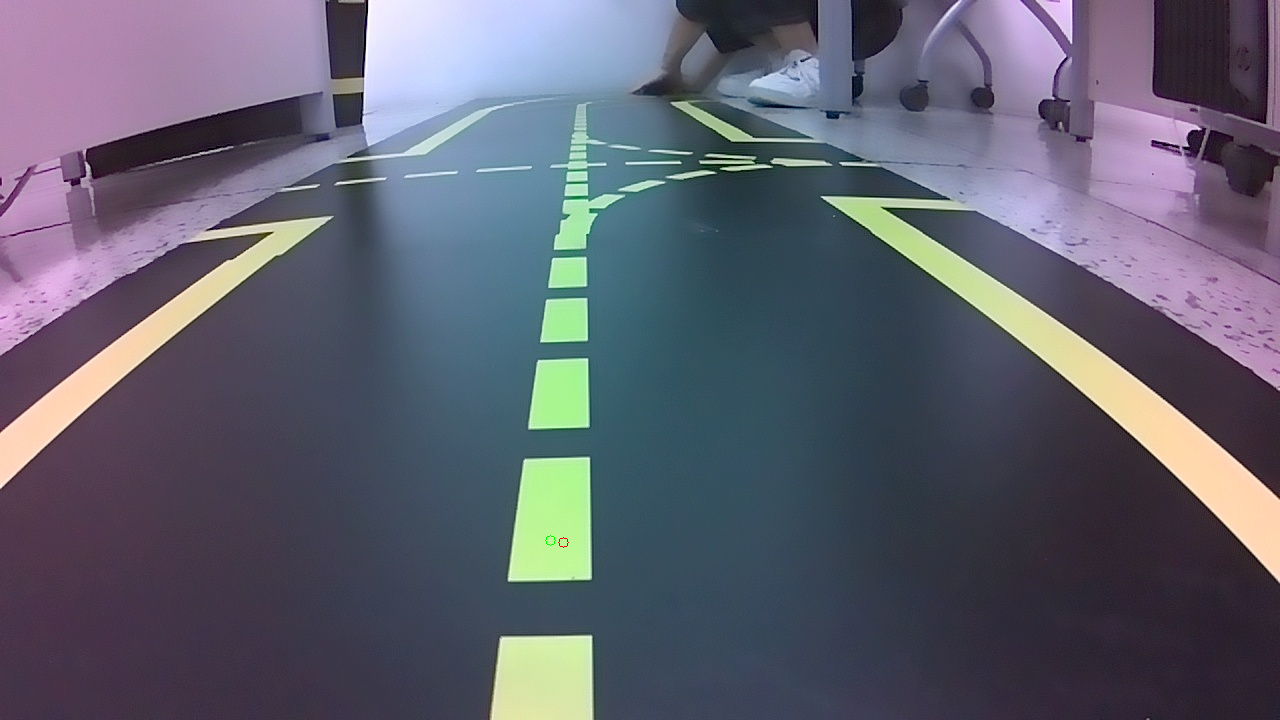

In [ ]:
import cv2
import copy
import numpy as np
import PIL.Image

img_filename_fmt = 'images0513two/20250513_{:06d}_{:06d}.jpg'
ann_filename = 'images0513two/annotation.txt'
with open(ann_filename, 'r') as f:
    data = [line.split() for line in f.readlines()]

filename, xpos, ypos = data[3]

xpos = int(xpos)
ypos = int(ypos)

image_ori = PIL.Image.open(filename)
width = image_ori.width
height = image_ori.height

with torch.no_grad():
    image = preprocess(image_ori)
    output = model(image).detach().cpu().numpy()
x, y = output[0]

x = (x / 2 + 0.5) * width
y = (y / 2 + 0.5) * height
print(x, y)

image_np = copy.deepcopy(np.asarray(image_ori))
cv2.circle(image_np, (int(x), int(y)), radius=5, color=(255, 0, 0))  # Pred
cv2.circle(image_np, (xpos, ypos), radius=5, color=(0, 255, 0))     # GT

PIL.Image.fromarray(image_np)

